In [60]:
import sys
sys.path.append('..')
from sqlalchemy import create_engine, text
import os

import geopandas as gpd
import pandas as pd
from geoalchemy2 import Geometry
from shapely.geometry import LineString

from config import RUTA_UNIDAD_ONE_DRIVE
from config import RUTA_LOCAL_ONE_DRIVE
from config import API_AMIGOCLOUD_TOKEN_ADM
from config import POSTGRES_UTEA

POSTGRES_UTEA['DATABASE'] = 'utea_precision'

In [48]:
PATH_SHPS = RUTA_UNIDAD_ONE_DRIVE + r"Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - PROGRAMA DE COSECHA\2026\SEGUIMIENTO_COSECHA\SHP_RECORRIDOS"

In [56]:
def obtener_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

def obtener_lotes_pendientes():
    engine = obtener_engine()
    # 1. Query para traer solo los registros con segmentos = FALSE
    query = text("""
        SELECT nombre_archivo
        FROM datos_cosecha.fechas 
        WHERE puntos_cargados IS FALSE
    """)
    lista_formateada = []
    try:
        with engine.connect() as conn:
            resultados = conn.execute(query)
            for fila in resultados:
                registro_string = f"{fila.nombre_archivo}"
                lista_formateada.append(registro_string)
        return lista_formateada
    except Exception as e:
        print(f"Error al recuperar datos: {e}")
        return []

def obtener_id_lote(conn, nombre_archivo):
    """Busca el ID de la tabla maestra usando el nombre del archivo."""
    try:
        query = text("""
            SELECT id FROM datos_cosecha.fechas 
            WHERE nombre_archivo = :nom_file
        """)
        res = conn.execute(query, {'nom_file': nombre_archivo}).fetchone()
        return res[0] if res else None
    except (IndexError, ValueError):
        return None

def preparar_geodataframe_utm(ruta_shp, lote_id):
    gdf = gpd.read_file(ruta_shp)
    gdf['IsoTime'] = pd.to_datetime(gdf['IsoTime'])
    #gdf.columns = [c.lower() for c in gdf.columns]
    gdf.columns = gdf.columns.str.lower()
    gdf = gdf.rename(columns={'geometry': 'geom'})
    gdf = gdf.set_geometry('geom')
    gdf = gdf.to_crs(epsg=32720)
    columnas_db = ['distance',
                   'swathwidth',
                   'vryldrcane',
                   'sectionid',
                   'crop',
                   'trash',
                   'time',
                   'heading',
                   'variety',
                   'elevation',
                   'isotime',
                   'machine',
                   'fuel',
                   'vehiclspee',
                   'producthas', 
                   'geom']
    gdf = gdf[columnas_db].copy()
    return gdf

def cargar_puntos_shps(ruta_carpeta):
    """Función principal que coordina la lectura y carga a Postgres."""
    engine = obtener_engine()
    pendientes = obtener_lotes_pendientes() # Tu función que filtra puntos_cargados IS FALSE
    for nombre_archivo in pendientes:
        ruta_shp = os.path.join(ruta_carpeta, f"{nombre_archivo}.shp")
        if not os.path.exists(ruta_shp):
            print(f"⚠️ Archivo no encontrado: {nombre_archivo}")
            continue
        try:
            with engine.begin() as conn:
                # 1. Identificar el lote
                lote_id = obtener_id_lote(conn, nombre_archivo)
                if lote_id is None:
                    print(f"❌ No existe registro maestro para: {nombre_archivo}")
                    continue
                # 2. Preparar los datos
                df_final = preparar_geodataframe_utm(ruta_shp, lote_id)
                # 3. Insertar detalles
                df_final.to_postgis(
                    'recorridos_cosecha', 
                    conn, 
                    schema='datos_cosecha', 
                    if_exists='append'
                )
                # 4. Actualizar estado
                conn.execute(text("""
                    UPDATE datos_cosecha.fechas 
                    SET puntos_cargados = TRUE 
                    WHERE id = :id
                """), {'id': lote_id})
                print(f"✅ {nombre_archivo}: {len(df_final)} puntos cargados.")
        except Exception as e:
            print(f"❌ Error procesando {nombre_archivo}: {str(e)}")

In [52]:
lotes_faltantes = obtener_lotes_pendientes()

print(f"Se encontraron {len(lotes_faltantes)} recorridos sin procesar:")
lotes_faltantes

Se encontraron 1 recorridos sin procesar:


['2026-04-23']

In [51]:
cargar_puntos_shps(PATH_SHPS)

In [54]:
ruta_shp = os.path.join(PATH_SHPS, f"2026-04-23.shp")

In [55]:
res = preparar_geodataframe_utm(ruta_shp, 1)

Index(['distance', 'swathwidth', 'vryldrcane', 'sectionid', 'crop', 'trash',
       'time', 'heading', 'variety', 'elevation', 'isotime', 'machine', 'fuel',
       'vehiclspee', 'producthas', 'geometry'],
      dtype='object')


<Axes: >

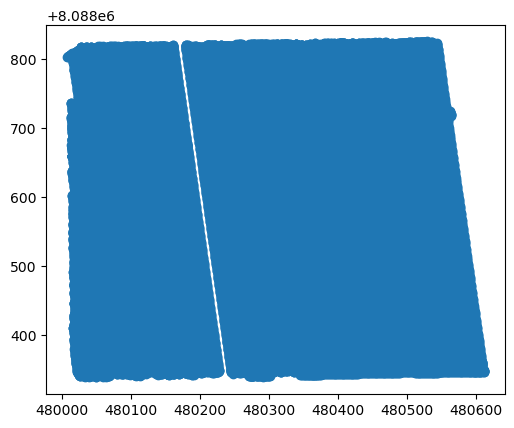

In [58]:
res.plot()

In [59]:
res

,distance,swathwidth,vryldrcane,sectionid,crop,trash,time,heading,variety,elevation,isotime,machine,fuel,vehiclspee,producthas,geom
0,0.250014,1.5,3.707340e-03,7239,133,6.74,5/27/2025 3:48:19 PM,87.017128,85-22,278.441188,2025-05-27 15:48:19.448000+00:00,1,0.002768,4.557775,a783dfe8,POINT (480270.953 8088340.329)
1,1.005054,1.5,2.787530e-03,7239,133,6.74,5/27/2025 3:48:20 PM,86.390295,85-22,278.434188,2025-05-27 15:48:20.243000+00:00,1,0.011275,4.566775,a783dfe8,POINT (480271.959 8088340.377)
2,1.254068,1.5,1.431700e-04,7239,133,0.00,5/27/2025 3:48:21 PM,86.244732,85-22,278.446188,2025-05-27 15:48:21.248000+00:00,1,0.014291,4.510975,a783dfe8,POINT (480273.213 8088340.449)
3,1.092068,1.5,7.020000e-06,7239,133,0.00,5/27/2025 3:48:22 PM,86.467107,85-22,278.463188,2025-05-27 15:48:22.248000+00:00,1,0.012760,4.084735,a783dfe8,POINT (480274.305 8088340.520)
4,0.623068,1.5,5.800000e-07,7239,133,0.00,5/27/2025 3:48:23 PM,86.499599,85-22,278.438188,2025-05-27 15:48:23.249000+00:00,1,0.010045,2.955055,a783dfe8,POINT (480274.928 8088340.562)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116465,0.635269,1.5,1.491500e-04,2124,133,0.00,6/16/2025 8:43:16 AM,171.164276,90-20,277.406153,2025-06-16 08:43:16.083000+00:00,1,0.001650,2.284982,1f12b9a9,POINT (480563.632 8088720.349)
116466,0.572269,1.5,1.446000e-05,2124,133,0.00,6/16/2025 8:43:17 AM,170.970826,90-20,277.426153,2025-06-16 08:43:17.083000+00:00,1,0.005613,2.116503,1f12b9a9,POINT (480563.725 8088719.784)
116467,0.589269,1.5,1.280000e-06,2124,133,0.00,6/16/2025 8:43:18 AM,170.587500,90-20,277.434153,2025-06-16 08:43:18.083000+00:00,1,0.003665,2.120823,1f12b9a9,POINT (480563.825 8088719.204)
116468,0.558269,1.5,1.200000e-07,2124,133,0.00,6/16/2025 8:43:19 AM,170.556804,90-20,277.437153,2025-06-16 08:43:19.083000+00:00,1,0.003778,2.063943,1f12b9a9,POINT (480563.917 8088718.654)


In [61]:
df = res.copy()

In [63]:
# 1. Asegurar que el tiempo esté en formato datetime y ordenar
df['isotime'] = pd.to_datetime(df['isotime'])
df = df.sort_values('isotime').reset_index(drop=True)

# 2. Creamos una copia de las geometrías desplazada hacia arriba (el punto siguiente)
next_geom = df['geom'].shift(-1)

# 3. Creamos los segmentos (LineString) uniendo el punto actual con el siguiente
# Usamos un list comprehension por eficiencia en datasets grandes (+100k filas)
lines = [
    LineString([p1, p2]) if p2 is not None else None 
    for p1, p2 in zip(df.geom[:-1], next_geom[:-1])
]

# 4. Creamos el nuevo GeoDataFrame de líneas
# Eliminamos la última fila porque no tiene un "punto siguiente" con el cual conectar
df_lines = df.iloc[:-1].copy()
df_lines.geom = lines

# Opcional: Eliminar segmentos que sean demasiado largos 
# (por si la cosechadora se apagó y se movió a otro lote)
# df_lines = df_lines[df_lines.geometry.length < 50]

In [66]:
df_lines

,distance,swathwidth,vryldrcane,sectionid,crop,trash,time,heading,variety,elevation,isotime,machine,fuel,vehiclspee,producthas,geom
0,0.250014,1.5,3.707340e-03,7239,133,6.74,5/27/2025 3:48:19 PM,87.017128,85-22,278.441188,2025-05-27 15:48:19.448000+00:00,1,0.002768,4.557775,a783dfe8,"LINESTRING (480270.953 8088340.329, 480271.959..."
1,1.005054,1.5,2.787530e-03,7239,133,6.74,5/27/2025 3:48:20 PM,86.390295,85-22,278.434188,2025-05-27 15:48:20.243000+00:00,1,0.011275,4.566775,a783dfe8,"LINESTRING (480271.959 8088340.377, 480273.213..."
2,1.254068,1.5,1.431700e-04,7239,133,0.00,5/27/2025 3:48:21 PM,86.244732,85-22,278.446188,2025-05-27 15:48:21.248000+00:00,1,0.014291,4.510975,a783dfe8,"LINESTRING (480273.213 8088340.449, 480274.305..."
3,1.092068,1.5,7.020000e-06,7239,133,0.00,5/27/2025 3:48:22 PM,86.467107,85-22,278.463188,2025-05-27 15:48:22.248000+00:00,1,0.012760,4.084735,a783dfe8,"LINESTRING (480274.305 8088340.520, 480274.928..."
4,0.623068,1.5,5.800000e-07,7239,133,0.00,5/27/2025 3:48:23 PM,86.499599,85-22,278.438188,2025-05-27 15:48:23.249000+00:00,1,0.010045,2.955055,a783dfe8,"LINESTRING (480274.928 8088340.562, 480274.700..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116464,0.658269,1.5,1.739093e-02,2124,133,0.00,6/16/2025 8:43:14 AM,172.173700,90-20,277.402153,2025-06-16 08:43:14.082000+00:00,1,0.003770,2.352663,1f12b9a9,"LINESTRING (480563.422 8088721.614, 480563.632..."
116465,0.635269,1.5,1.491500e-04,2124,133,0.00,6/16/2025 8:43:16 AM,171.164276,90-20,277.406153,2025-06-16 08:43:16.083000+00:00,1,0.001650,2.284982,1f12b9a9,"LINESTRING (480563.632 8088720.349, 480563.725..."
116466,0.572269,1.5,1.446000e-05,2124,133,0.00,6/16/2025 8:43:17 AM,170.970826,90-20,277.426153,2025-06-16 08:43:17.083000+00:00,1,0.005613,2.116503,1f12b9a9,"LINESTRING (480563.725 8088719.784, 480563.825..."
116467,0.589269,1.5,1.280000e-06,2124,133,0.00,6/16/2025 8:43:18 AM,170.587500,90-20,277.434153,2025-06-16 08:43:18.083000+00:00,1,0.003665,2.120823,1f12b9a9,"LINESTRING (480563.825 8088719.204, 480563.917..."


In [72]:
df_lines['isotime'] = df_lines['isotime'].astype(str)

In [73]:
df_lines.to_file("lineas.shp", driver="ESRI Shapefile")